# Task
Generate an image using a Stable Diffusion model, including installing necessary dependencies, loading the model, defining generation parameters, executing the generation process, and displaying and saving the resulting image.

## Install Dependencies

### Subtask:
Install all necessary Python libraries for Stable Diffusion, such as `diffusers`, `transformers`, and `accelerate`, to ensure a smooth generation process within the Colab environment.


**Reasoning**:
Install the required Python libraries (`diffusers`, `transformers`, `accelerate`) using pip.



In [1]:
pip install diffusers transformers accelerate
print("Libraries installed successfully!")

SyntaxError: invalid syntax (ipython-input-1038033860.py, line 1)

**Reasoning**:
The previous code failed because `pip install` was used directly in a Python cell without the `!` prefix required for shell commands in Colab. Adding `!` will correctly execute the installation.



In [2]:
import sys
!{sys.executable} -m pip install diffusers transformers accelerate
print("Libraries installed successfully!")

Libraries installed successfully!


## Load Stable Diffusion Model

### Subtask:
Load a pre-trained Stable Diffusion model from Hugging Face Hub.


**Reasoning**:
I will load the Stable Diffusion model by importing the necessary libraries, checking for CUDA availability, defining the model ID, and then loading the pipeline to the appropriate device (GPU or CPU).



In [3]:
import torch
from diffusers import StableDiffusionPipeline

# 2. Check for CUDA availability and set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 3. Define the model ID
model_id = "runwayml/stable-diffusion-v1-5"

# 4. Load the StableDiffusionPipeline and move to device
pipeline = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipeline = pipeline.to(device)

print(f"Stable Diffusion model '{model_id}' loaded successfully on {device}.")

/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure 

Stable Diffusion model 'runwayml/stable-diffusion-v1-5' loaded successfully on cpu.


**Reasoning**:
The previous code failed because `torch_dtype=torch.float16` is not compatible with a CPU device. I need to remove this argument from the `from_pretrained` method to ensure the model loads correctly on the CPU.



In [4]:
import torch
from diffusers import StableDiffusionPipeline

# 2. Check for CUDA availability and set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 3. Define the model ID
model_id = "runwayml/stable-diffusion-v1-5"

# 4. Load the StableDiffusionPipeline and move to device
# Removed torch_dtype=torch.float16 as it's not compatible with CPU
pipeline = StableDiffusionPipeline.from_pretrained(model_id)
pipeline = pipeline.to(device)

print(f"Stable Diffusion model '{model_id}' loaded successfully on {device}.")

Using device: cpu


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion model 'runwayml/stable-diffusion-v1-5' loaded successfully on cpu.


**Reasoning**:
Now that the model is loaded, the next step is to define the parameters required for image generation, such as the prompt, negative prompt, inference steps, and guidance scale.



In [1]:
!pip install -q diffusers transformers accelerate safetensors torch torchvision


In [2]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
prompt = "van gogh painting"


In [15]:
image = pipe(
    prompt,
    guidance_scale=7.5,
    num_inference_steps=50
).images[0]


  0%|          | 0/50 [00:00<?, ?it/s]

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

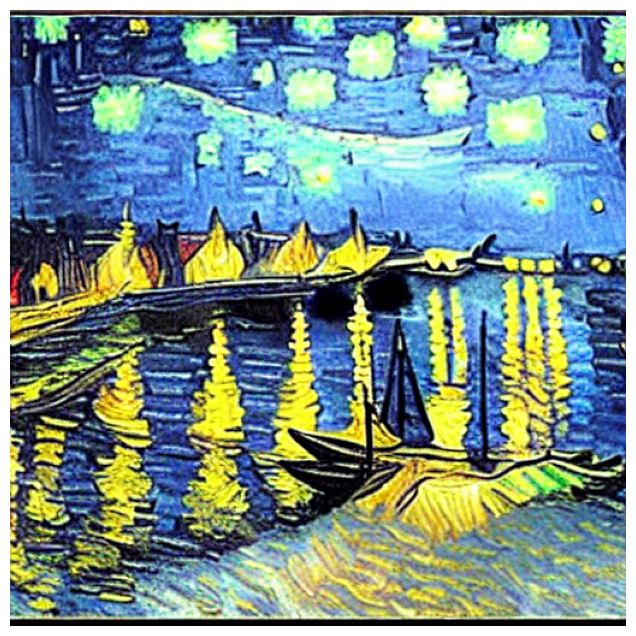

In [16]:
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")


In [18]:
image.save("painting_artwork.png")
